# Gold Volatility Analysis

### Quantitative Analysis of Gold Futures Volatility and Risk

This notebook presents a complete quantitative analysis of historical
COMEX Gold Futures data, covering return analysis, volatility modeling,
GARCH estimation, Value at Risk (VaR), and Expected Shortfall (ES).

---

### Project Workflow

1. Data Collection
2. Data Cleaning & Exploratory Data Analysis
3. Return Analysis
4. Volatility Analysis
5. GARCH Modeling
6. Value at Risk & Expected Shortfall

---

**Data Source:** Yahoo Finance  
**Ticker:** GC=F  
**Asset:** COMEX Gold Futures

# Phase 1 — Data Collection

Historical Gold Futures data is collected from Yahoo Finance and stored
as raw CSV data for subsequent analysis.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yfinance as yf
from arch import arch_model

## 2. Define Project Paths

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "Data" / "raw"
PROCESSED_DIR = BASE_DIR / "Data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data path:", RAW_DIR)
print("Processed data path:", PROCESSED_DIR)

Raw data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw
Processed data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed


## 3. Download Historical Gold Data

In [3]:
ticker = "GC=F"

gold_df = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False
)

gold_df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## 4. Initial Data Inspection

In [4]:
print("Shape:", gold_df.shape)
print("\nColumns:")
print(gold_df.columns)

print("\nMissing Values:")
print(gold_df.isnull().sum())

gold_df.info()

Shape: (4207, 6)

Columns:
MultiIndex([('Adj Close', 'GC=F'),
            (    'Close', 'GC=F'),
            (     'High', 'GC=F'),
            (      'Low', 'GC=F'),
            (     'Open', 'GC=F'),
            (   'Volume', 'GC=F')],
           names=['Price', 'Ticker'])

Missing Values:
Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64
<class 'pandas.DataFrame'>
DatetimeIndex: 4207 entries, 2010-01-04 to 2026-09-24
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GC=F)  4207 non-null   float64
 1   (Close, GC=F)      4207 non-null   float64
 2   (High, GC=F)       4207 non-null   float64
 3   (Low, GC=F)        4207 non-null   float64
 4   (Open, GC=F)       4207 non-null   float64
 5   (Volume, GC=F)     4207 non-null   int64  
dtypes: float64(5), int64(1)
memory usage

In [5]:
display(gold_df.head())

display(gold_df.tail())

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2026-09-18,4424.899902,4424.899902,4439.799805,4372.200195,4381.600098,142919
2026-09-21,4383.899902,4383.899902,4422.100098,4360.299805,4413.000000,138203
2026-09-22,4376.399902,4376.399902,4414.100098,4327.600098,4382.500000,178132
2026-09-23,4318.399902,4318.399902,4407.500000,4310.700195,4394.700195,178132
2026-09-24,4305.600098,4305.600098,4312.799805,4305.299805,4309.500000,504


## 5. Save Raw Data

In [6]:
output_file = RAW_DIR / "gold_price.csv"

gold_df.to_csv(output_file)

print(f"File saved successfully:\n{output_file}")

File saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw\gold_price.csv


# Phase 2 — Data Cleaning & Exploratory Data Analysis

In this phase, the raw dataset is cleaned and inspected for missing
values, duplicate dates, invalid prices, chronological ordering,
and descriptive statistics.

## 1. Load Raw Data

In [7]:
raw_file = RAW_DIR / "gold_price.csv"

gold_raw = pd.read_csv(
    raw_file,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## 2. Flatten Column Structure

In [8]:
gold_raw.columns = gold_raw.columns.get_level_values(0)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## 3. Select Relevant Columns

In [9]:
gold = gold_raw[
    ["Open", "High", "Low", "Close", "Volume"]
].copy()

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


In [10]:
print("Index type:", type(gold.index))
print("Start date:", gold.index.min())
print("End date:", gold.index.max())

Index type: <class 'pandas.DatetimeIndex'>
Start date: 2010-01-04 00:00:00
End date: 2026-09-24 00:00:00


In [11]:
gold.index.name = "Date"

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## 4. Data Quality Checks

In [12]:
gold.isnull().sum()

Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [13]:
print("Duplicate dates:", gold.index.duplicated().sum())

Duplicate dates: 0


In [14]:
price_columns = ["Open", "High", "Low", "Close"]

(gold[price_columns] <= 0).sum()

Price
Open     0
High     0
Low      0
Close    0
dtype: int64

In [15]:
print("Sorted by date:", gold.index.is_monotonic_increasing)

Sorted by date: True


## 5. Descriptive Statistics

In [16]:
gold.describe()

Price,Open,High,Low,Close,Volume
count,4207.000000,4207.000000,4207.000000,4207.000000,4207.000000
mean,1793.988329,1806.802258,1780.544450,1794.052294,77916.745662
std,830.499736,843.156162,817.515098,830.903830,105577.175667
min,1052.199951,1062.000000,1045.199951,1050.800049,0.000000
25%,1274.149963,1279.299988,1269.299988,1273.599976,79.000000
50%,1559.300049,1569.099976,1549.800049,1560.599976,597.000000
75%,1879.649963,1896.250000,1866.399963,1879.549988,167867.000000
max,5415.700195,5586.200195,5272.899902,5318.399902,570055.000000


## 6. Historical Gold Price

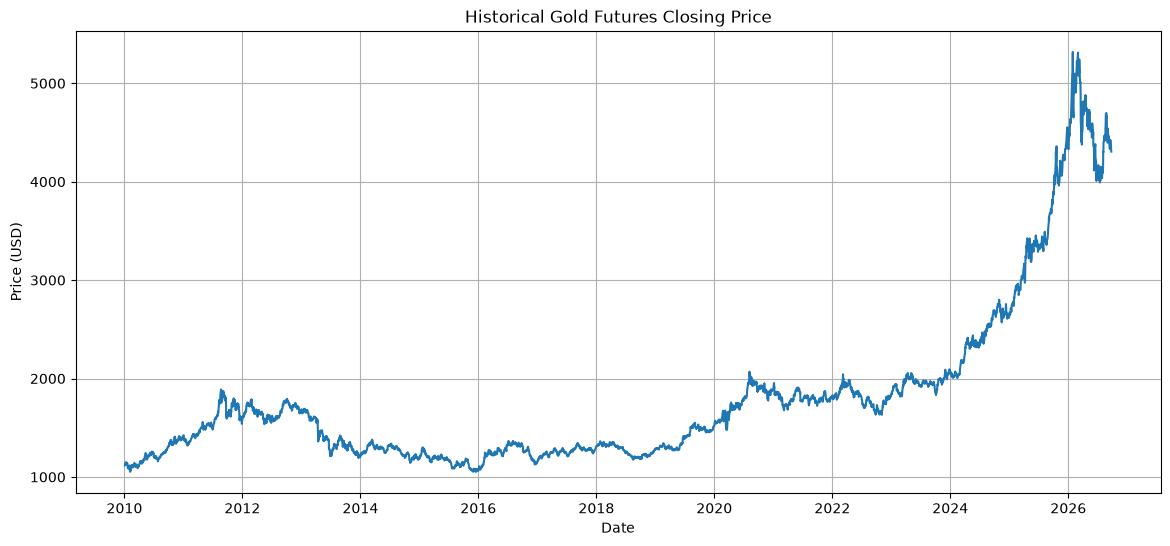

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(gold.index, gold["Close"])

plt.title("Historical Gold Futures Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

## 7. Save Clean Dataset

In [18]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold.to_csv(processed_file)

print(f"Processed data saved successfully:\n{processed_file}")

Processed data saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_clean.csv


### Phase 2 Summary

The dataset contains 4,207 observations with no missing values or
duplicate dates after cleaning.

The historical price series shows substantial changes in the level of
gold futures prices over the sample period, motivating further analysis
of returns and volatility.

# Phase 3 — Return Analysis

This phase transforms price information into daily and logarithmic
returns and examines the statistical characteristics of the return
distribution.

## 1. Load Clean Data

In [19]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold = pd.read_csv(
    processed_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## 2. Calculate Daily Returns

In [20]:
gold["Daily_Return"] = gold["Close"].pct_change()

gold[["Close", "Daily_Return"]].head(10)

,Close,Daily_Return
Date,,
2010-01-04,1117.699951,NaN
2010-01-05,1118.099976,0.000358
2010-01-06,1135.900024,0.015920
2010-01-07,1133.099976,-0.002465
2010-01-08,1138.199951,0.004501
2010-01-11,1150.699951,0.010982
2010-01-12,1128.900024,-0.018945
2010-01-13,1136.400024,0.006644
2010-01-14,1142.599976,0.005456


## 3. Calculate Log Returns

In [21]:
gold["Log_Return"] = np.log(
    gold["Close"] / gold["Close"].shift(1)
)

gold[["Close", "Daily_Return", "Log_Return"]].head(10)

,Close,Daily_Return,Log_Return
Date,,,
2010-01-04,1117.699951,NaN,NaN
2010-01-05,1118.099976,0.000358,0.000358
2010-01-06,1135.900024,0.015920,0.015795
2010-01-07,1133.099976,-0.002465,-0.002468
2010-01-08,1138.199951,0.004501,0.004491
2010-01-11,1150.699951,0.010982,0.010922
2010-01-12,1128.900024,-0.018945,-0.019127
2010-01-13,1136.400024,0.006644,0.006622
2010-01-14,1142.599976,0.005456,0.005441


## 4. Check Missing Values

In [22]:
gold[["Daily_Return", "Log_Return"]].isnull().sum()

Daily_Return    1
Log_Return      1
dtype: int64

## 5. Return Descriptive Statistics

In [23]:
return_stats = gold[
    ["Daily_Return", "Log_Return"]
].describe()

return_stats

,Daily_Return,Log_Return
count,4206.000000,4206.000000
mean,0.000380,0.000321
std,0.010838,0.010875
min,-0.107796,-0.114060
25%,-0.004671,-0.004682
50%,0.000428,0.000428
75%,0.005978,0.005960
max,0.060697,0.058926


## 6. Return Distribution

In [24]:
return_distribution = pd.DataFrame({
    "Mean": gold[["Daily_Return", "Log_Return"]].mean(),
    "Std": gold[["Daily_Return", "Log_Return"]].std(),
    "Skewness": gold[["Daily_Return", "Log_Return"]].skew(),
    "Kurtosis": gold[["Daily_Return", "Log_Return"]].kurt()
})

return_distribution

,Mean,Std,Skewness,Kurtosis
Daily_Return,0.000380,0.010838,-0.599516,6.697139
Log_Return,0.000321,0.010875,-0.741482,7.550958


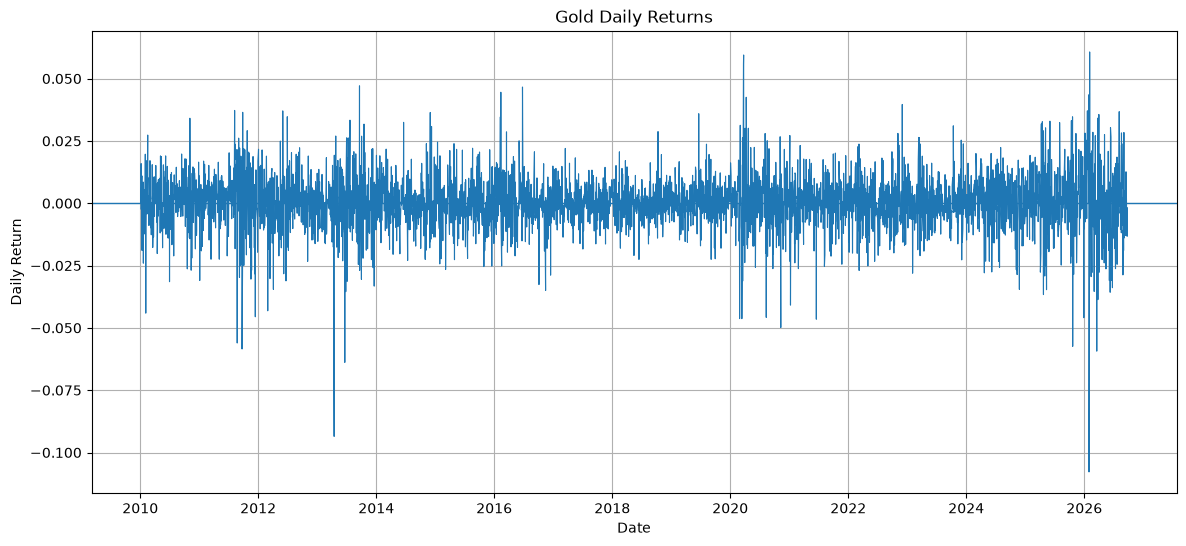

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Daily_Return"],
    linewidth=0.8
)

plt.title("Gold Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.axhline(0, linewidth=1)

plt.grid(True)
plt.show()

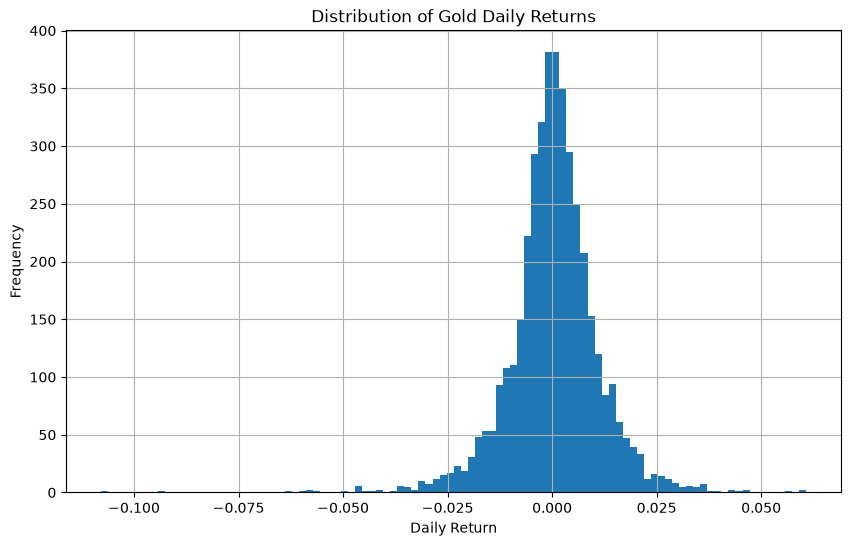

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    gold["Daily_Return"].dropna(),
    bins=100
)

plt.title("Distribution of Gold Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

In [27]:
largest_positive = gold["Daily_Return"].nlargest(10)

largest_negative = gold["Daily_Return"].nsmallest(10)

print("Largest Positive Returns:")
display(largest_positive)

print("\nLargest Negative Returns:")
display(largest_negative)

Largest Positive Returns:


Date
2026-02-03    0.060697
2020-03-24    0.059477
2020-03-23    0.055930
2013-09-19    0.047102
2016-06-24    0.046622
2016-02-11    0.044530
2026-01-28    0.043482
2020-04-09    0.042512
2022-12-01    0.039633
2011-08-08    0.037239
Name: Daily_Return, dtype: float64


Largest Negative Returns:


Date
2026-01-30   -0.107796
2013-04-15   -0.093538
2013-06-20   -0.063847
2026-03-19   -0.059332
2011-09-23   -0.058475
2025-10-21   -0.057416
2011-08-24   -0.056073
2020-11-09   -0.049854
2021-06-17   -0.046524
2020-03-13   -0.046310
Name: Daily_Return, dtype: float64

## 7. Save Return Dataset

In [28]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold.to_csv(returns_file)

print(f"Return dataset saved successfully:\n{returns_file}")

Return dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_returns.csv


### Phase 3 Summary

Gold log returns have a small positive average daily return and
approximately 1.09% daily standard deviation.

The return distribution exhibits negative skewness and high excess
kurtosis, indicating asymmetric behavior and heavier tails than a
normal distribution.

These characteristics motivate the use of volatility models and
non-normal innovation distributions in the next phases.

# Phase 4 — Volatility Analysis

This phase measures historical and time-varying volatility using
rolling standard deviations and examines evidence of volatility
clustering.

## 1. Load Return Data

In [29]:
returns_file = PROCESSED_DIR / "gold_returns.csv"

gold = pd.read_csv(
    returns_file,
    parse_dates=["Date"],
    index_col="Date"
)

gold.head()

,Open,High,Low,Close,Volume,Daily_Return,Log_Return
Date,,,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184,NaN,NaN
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53,0.000358,0.000358
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363,0.015920,0.015795
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56,-0.002465,-0.002468
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54,0.004501,0.004491


## 2. Historical Daily Volatility

In [30]:
daily_volatility = gold["Daily_Return"].std()

print(f"Daily Historical Volatility: {daily_volatility:.6%}")

Daily Historical Volatility: 1.083792%


## 3. Annualized Volatility

In [31]:
annualized_volatility = daily_volatility * np.sqrt(252)

print(f"Annualized Volatility: {annualized_volatility:.6%}")

Annualized Volatility: 17.204660%


## 4. Rolling Volatility

In [32]:
gold["Volatility_7D"] = (
    gold["Daily_Return"]
    .rolling(window=7)
    .std()
)

gold["Volatility_30D"] = (
    gold["Daily_Return"]
    .rolling(window=30)
    .std()
)

gold[[
    "Daily_Return",
    "Volatility_7D",
    "Volatility_30D"
]].tail()

,Daily_Return,Volatility_7D,Volatility_30D
Date,,,
2026-09-18,0.005728,0.009319,0.013596
2026-09-21,-0.009266,0.008838,0.013048
2026-09-22,-0.001711,0.008830,0.013023
2026-09-23,-0.013253,0.008903,0.013197
2026-09-24,-0.002964,0.008831,0.013139


In [33]:
gold["Annualized_Volatility_7D"] = (
    gold["Volatility_7D"] * np.sqrt(252)
)

gold["Annualized_Volatility_30D"] = (
    gold["Volatility_30D"] * np.sqrt(252)
)

gold[[
    "Annualized_Volatility_7D",
    "Annualized_Volatility_30D"
]].tail()

,Annualized_Volatility_7D,Annualized_Volatility_30D
Date,,
2026-09-18,0.147939,0.215835
2026-09-21,0.140292,0.207138
2026-09-22,0.140167,0.206729
2026-09-23,0.141333,0.209492
2026-09-24,0.140182,0.208571


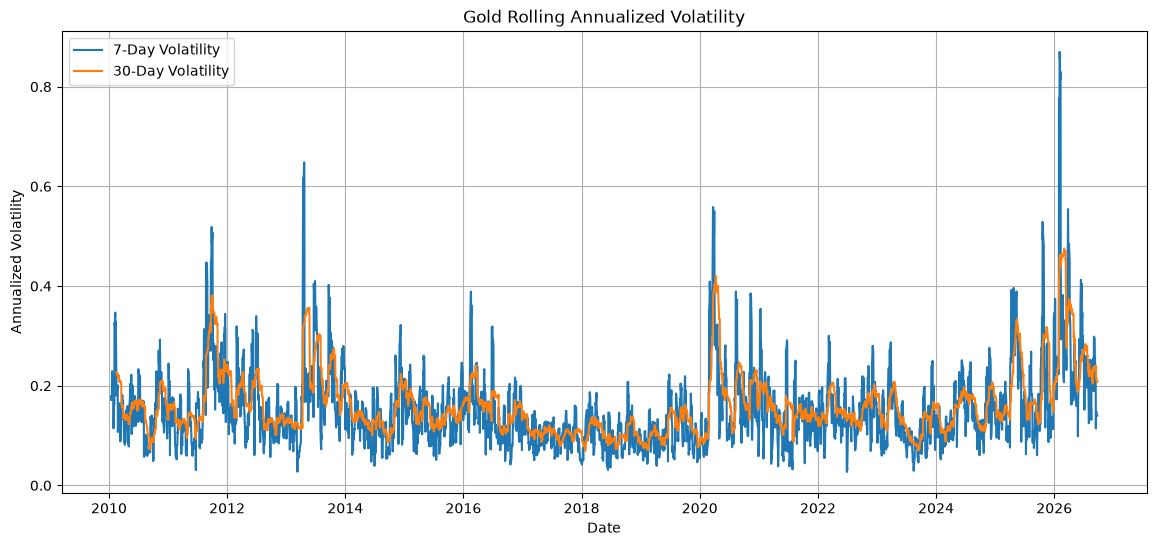

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_7D"],
    label="7-Day Volatility"
)

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30-Day Volatility"
)

plt.title("Gold Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
volatility_stats = gold[
    [
        "Volatility_7D",
        "Volatility_30D",
        "Annualized_Volatility_7D",
        "Annualized_Volatility_30D"
    ]
].describe()

volatility_stats

,Volatility_7D,Volatility_30D,Annualized_Volatility_7D,Annualized_Volatility_30D
count,4200.000000,4177.000000,4200.000000,4177.000000
mean,0.009624,0.010101,0.152774,0.160347
std,0.005146,0.003992,0.081691,0.063364
min,0.001698,0.004324,0.026953,0.068639
25%,0.006264,0.007551,0.099436,0.119862
50%,0.008498,0.009101,0.134909,0.144479
75%,0.011558,0.011480,0.183470,0.182233
max,0.054785,0.029950,0.869691,0.475444


## 5. Absolute Returns

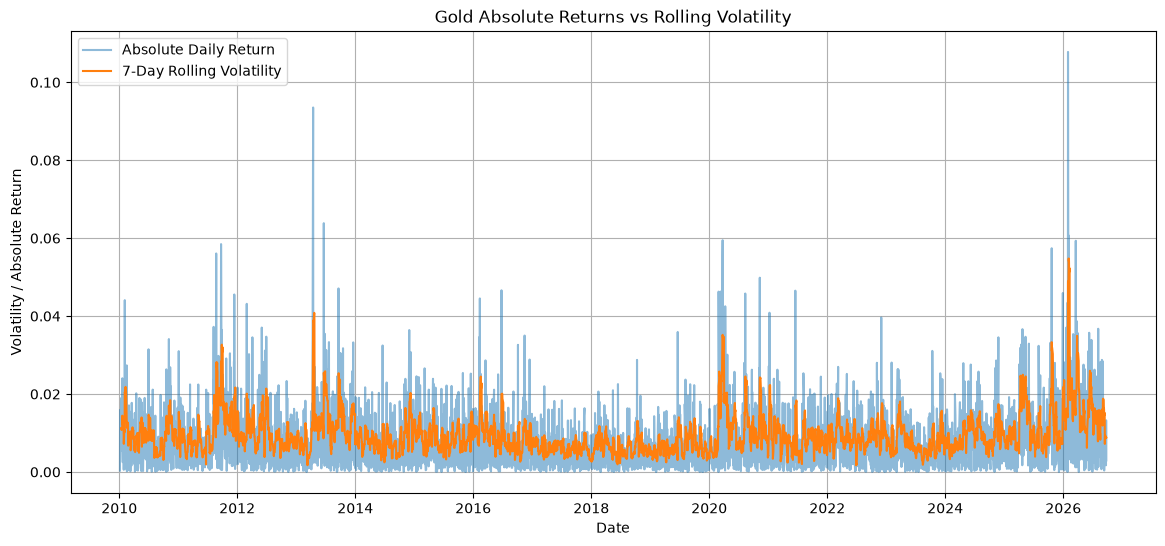

In [36]:
gold["Absolute_Return"] = gold["Daily_Return"].abs()

plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Absolute_Return"],
    label="Absolute Daily Return",
    alpha=0.5
)

plt.plot(
    gold.index,
    gold["Volatility_7D"],
    label="7-Day Rolling Volatility"
)

plt.title("Gold Absolute Returns vs Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility / Absolute Return")

plt.legend()
plt.grid(True)

plt.show()

## 6. Volatility Clustering

In [37]:
volatility_correlation = gold[
    ["Absolute_Return", "Volatility_7D"]
].corr()

volatility_correlation

,Absolute_Return,Volatility_7D
Absolute_Return,1.000000,0.466122
Volatility_7D,0.466122,1.000000


## 7. Save Volatility Dataset

In [38]:
volatility_file = PROCESSED_DIR / "gold_volatility.csv"

gold.to_csv(volatility_file)

print(f"Volatility dataset saved successfully:\n{volatility_file}")

Volatility dataset saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_volatility.csv


### Phase 4 Summary

The estimated daily volatility is approximately 1.08%, corresponding
to an annualized volatility of approximately 17.20%.

Rolling volatility varies considerably over time, demonstrating that
gold market volatility is not constant.

The relationship between absolute returns and rolling volatility also
provides visual evidence of volatility clustering.

# Phase 5 — GARCH Volatility Modeling

This phase models time-varying conditional volatility using a
GARCH(1,1) framework.

Both Normal and Student-t innovation distributions are evaluated.
The Student-t specification is then used for the subsequent risk
analysis.

## 1. Prepare Returns for GARCH

In [39]:
returns = gold["Log_Return"].dropna() * 100

returns.describe()

count    4206.000000
mean        0.032065
std         1.087463
min       -11.405996
25%        -0.468199
50%         0.042822
75%         0.595985
max         5.892645
Name: Log_Return, dtype: float64

In [40]:
garch_model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")

print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6016.31
Distribution:                  Normal   AIC:                           12040.6
Method:            Maximum Likelihood   BIC:                           12066.0
                                        No. Observations:                 4206
Date:                Fri, Sep 25 2026   Df Residuals:                     4205
Time:                        01:57:11   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0212  1.533e-02      1.382      0.167 

### GARCH Volatility Persistence

The persistence of volatility is measured by the sum of the ARCH
and GARCH coefficients:

Persistence = α₁ + β₁

A value close to 1 indicates that volatility shocks tend to persist
for a relatively long period.

In [41]:
omega = garch_result.params["omega"]
alpha = garch_result.params["alpha[1]"]
beta = garch_result.params["beta[1]"]

persistence = alpha + beta

print(f"Omega: {omega:.4f}")
print(f"Alpha: {alpha:.4f}")
print(f"Beta: {beta:.4f}")
print(f"Volatility Persistence (α + β): {persistence:.4f}")

Omega: 0.0178
Alpha: 0.0504
Beta: 0.9350
Volatility Persistence (α + β): 0.9854


In [42]:
gold["GARCH_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_Volatility"] = (
    garch_result.conditional_volatility
)

gold[["Log_Return", "GARCH_Volatility"]].tail()

,Log_Return,GARCH_Volatility
Date,,
2026-09-18,0.005711,1.281804
2026-09-21,-0.009309,1.252685
2026-09-22,-0.001712,1.237192
2026-09-23,-0.013342,1.204482
2026-09-24,-0.002968,1.211108


In [43]:
gold["GARCH_Annualized_Volatility"] = (
    gold["GARCH_Volatility"] * np.sqrt(252)
)

gold[["GARCH_Volatility", "GARCH_Annualized_Volatility"]].describe()

,GARCH_Volatility,GARCH_Annualized_Volatility
count,4206.000000,4206.000000
mean,1.046624,16.614637
std,0.307739,4.885208
min,0.646926,10.269624
25%,0.849438,13.484412
50%,0.966087,15.336154
75%,1.144540,18.169007
max,3.159815,50.160506


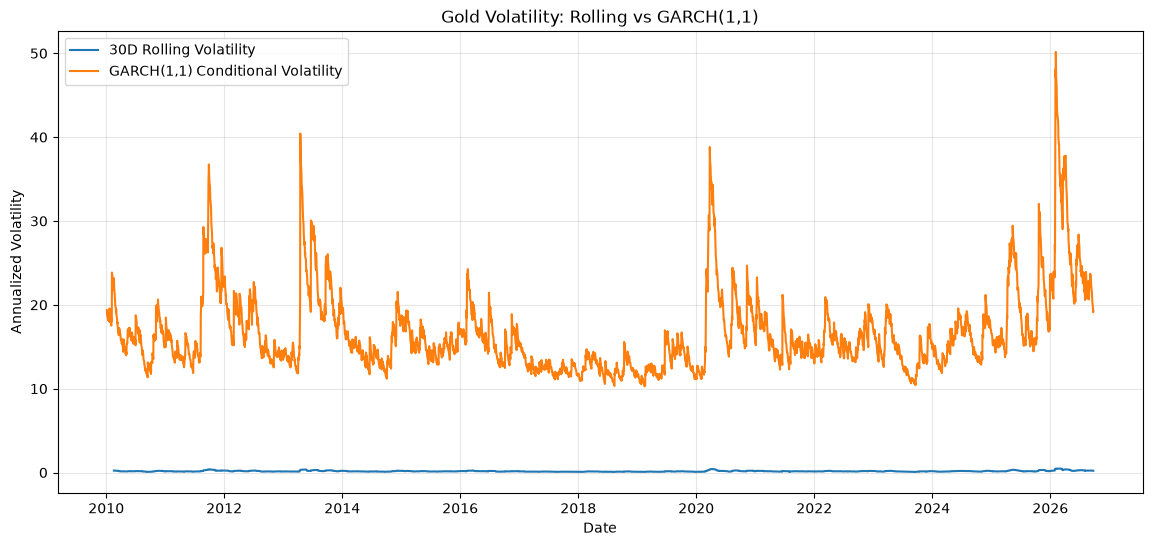

In [44]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_Annualized_Volatility"],
    label="GARCH(1,1) Conditional Volatility"
)

plt.title("Gold Volatility: Rolling vs GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [45]:
gold["GARCH_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_Volatility"] = (
    garch_result.conditional_volatility
)

gold["GARCH_Annualized_Volatility"] = (
    gold["GARCH_Volatility"] * np.sqrt(252)
)

print(gold[[
    "GARCH_Volatility",
    "GARCH_Annualized_Volatility"
]].describe())

       GARCH_Volatility  GARCH_Annualized_Volatility
count       4206.000000                  4206.000000
mean           1.046624                    16.614637
std            0.307739                     4.885208
min            0.646926                    10.269624
25%            0.849438                    13.484412
50%            0.966087                    15.336154
75%            1.144540                    18.169007
max            3.159815                    50.160506


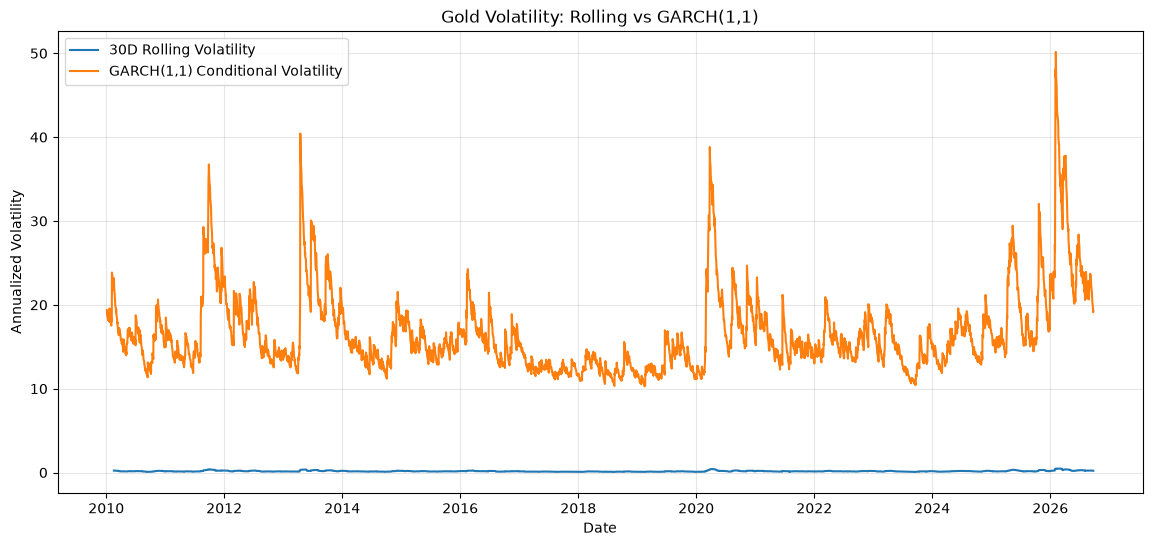

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_Annualized_Volatility"],
    label="GARCH(1,1) Conditional Volatility"
)

plt.title("Gold Volatility: Rolling vs GARCH(1,1)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### GARCH Model Diagnostics

Standardized residuals are examined to evaluate whether the GARCH model
has adequately captured the time-varying volatility structure.

In [47]:
standardized_residuals = garch_result.std_resid

standardized_residuals.describe()

count    4206.000000
mean        0.011411
std         1.000320
min        -7.552798
25%        -0.497098
50%         0.023053
75%         0.572649
max         4.997866
Name: std_resid, dtype: float64

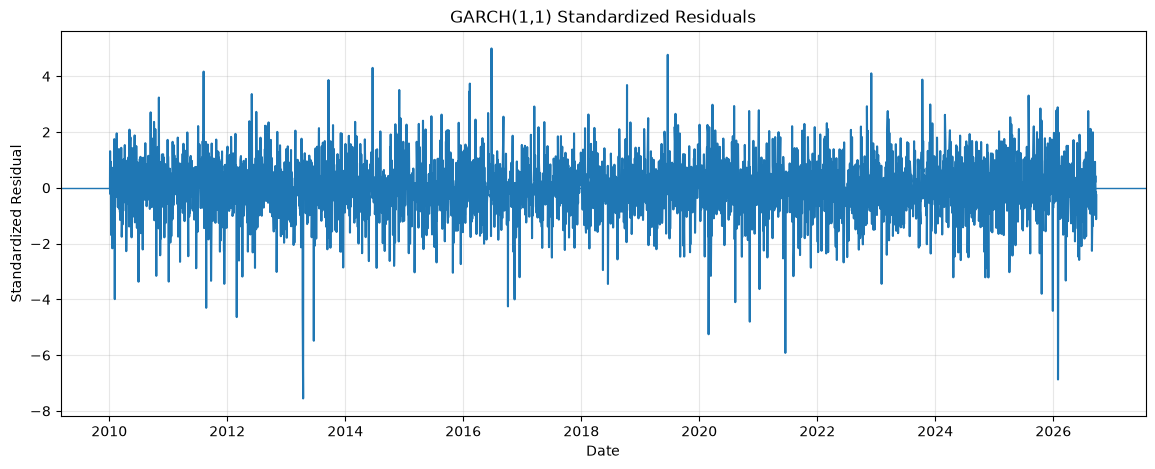

In [48]:
plt.figure(figsize=(14, 5))

plt.plot(
    standardized_residuals.index,
    standardized_residuals
)

plt.axhline(0, linewidth=1)

plt.title("GARCH(1,1) Standardized Residuals")
plt.xlabel("Date")
plt.ylabel("Standardized Residual")

plt.grid(alpha=0.3)
plt.show()

In [49]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(
    standardized_residuals.dropna() ** 2,
    lags=[10, 20],
    return_df=True
)

lb_test

,lb_stat,lb_pvalue
10,7.387894,0.688388
20,11.773091,0.923665


In [50]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Standardized residuals
standardized_residuals = garch_result.std_resid

print("=== Standardized Residuals ===")
print(standardized_residuals.describe())

# Ljung-Box test on squared standardized residuals
lb_test = acorr_ljungbox(
    standardized_residuals.dropna() ** 2,
    lags=[10, 20],
    return_df=True
)

print("\n=== Ljung-Box Test on Squared Standardized Residuals ===")
print(lb_test)

=== Standardized Residuals ===
count    4206.000000
mean        0.011411
std         1.000320
min        -7.552798
25%        -0.497098
50%         0.023053
75%         0.572649
max         4.997866
Name: std_resid, dtype: float64

=== Ljung-Box Test on Squared Standardized Residuals ===
      lb_stat  lb_pvalue
10   7.387894   0.688388
20  11.773091   0.923665


### GARCH(1,1) with Student-t Distribution

The return distribution showed significant excess kurtosis and fat tails.
Therefore, a second GARCH(1,1) model is estimated using a Student-t
distribution instead of the normal distribution.

The models are compared using AIC and BIC.

In [51]:
garch_t_model = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_t_result = garch_t_model.fit(disp="off")

print(garch_t_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5794.57
Distribution:      Standardized Student's t   AIC:                           11599.1
Method:                  Maximum Likelihood   BIC:                           11630.9
                                              No. Observations:                 4206
Date:                      Fri, Sep 25 2026   Df Residuals:                     4205
Time:                              01:57:12   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [52]:
comparison = pd.DataFrame({
    "Model": [
        "GARCH(1,1) - Normal",
        "GARCH(1,1) - Student-t"
    ],
    "Log_Likelihood": [
        garch_result.loglikelihood,
        garch_t_result.loglikelihood
    ],
    "AIC": [
        garch_result.aic,
        garch_t_result.aic
    ],
    "BIC": [
        garch_result.bic,
        garch_t_result.bic
    ],
    "Alpha": [
        garch_result.params["alpha[1]"],
        garch_t_result.params["alpha[1]"]
    ],
    "Beta": [
        garch_result.params["beta[1]"],
        garch_t_result.params["beta[1]"]
    ],
    "Persistence": [
        garch_result.params["alpha[1]"] + garch_result.params["beta[1]"],
        garch_t_result.params["alpha[1]"] + garch_t_result.params["beta[1]"]
    ]
})

comparison

,Model,Log_Likelihood,AIC,BIC,Alpha,Beta,Persistence
0,"GARCH(1,1) - Normal",-6016.312533,12040.625065,12066.002135,0.050382,0.934987,0.985369
1,"GARCH(1,1) - Student-t",-5794.568414,11599.136829,11630.858166,0.035388,0.958106,0.993494


### Final GARCH Model Selection

Two GARCH(1,1) specifications were evaluated using Normal and
Student-t innovations.

The Student-t specification produced lower AIC and BIC values
and a higher log-likelihood than the Normal specification.

Given the heavy-tailed characteristics observed in gold returns,
the Student-t GARCH(1,1) model is selected as the primary volatility
model for the subsequent risk analysis.

In [53]:
gold["GARCH_T_Volatility"] = np.nan

gold.loc[returns.index, "GARCH_T_Volatility"] = (
    garch_t_result.conditional_volatility
)

gold["GARCH_T_Annualized_Volatility"] = (
    gold["GARCH_T_Volatility"] * np.sqrt(252)
)

print(
    gold[
        [
            "GARCH_T_Volatility",
            "GARCH_T_Annualized_Volatility"
        ]
    ].describe()
)

       GARCH_T_Volatility  GARCH_T_Annualized_Volatility
count         4206.000000                    4206.000000
mean             1.065856                      16.919941
std              0.305838                       4.855023
min              0.650705                      10.329629
25%              0.867324                      13.768335
50%              0.987484                      15.675822
75%              1.167940                      18.540479
max              2.815482                      44.694384


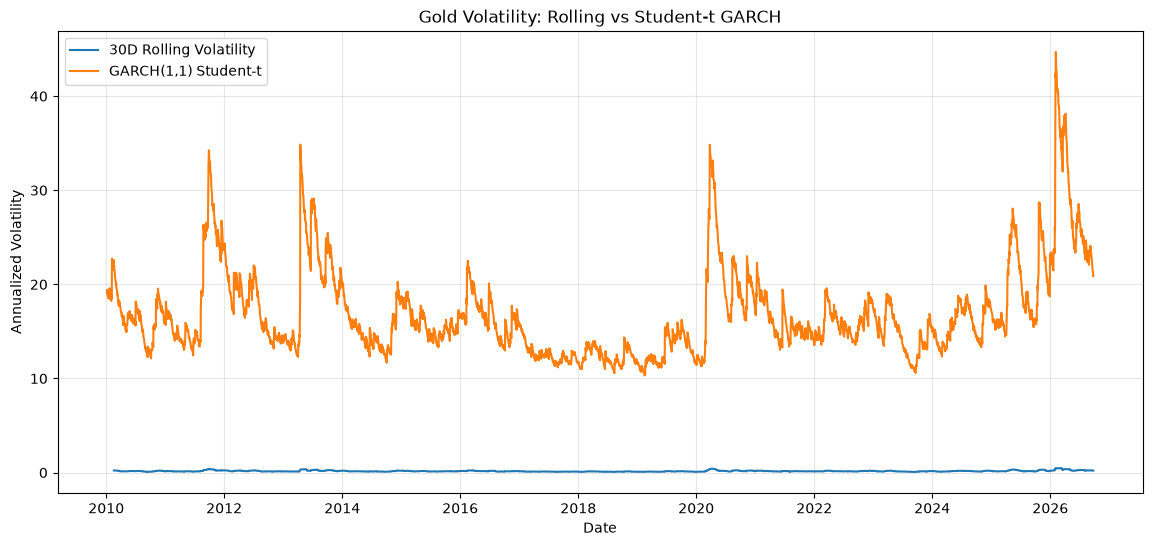

In [54]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["Annualized_Volatility_30D"],
    label="30D Rolling Volatility"
)

plt.plot(
    gold.index,
    gold["GARCH_T_Annualized_Volatility"],
    label="GARCH(1,1) Student-t"
)

plt.title("Gold Volatility: Rolling vs Student-t GARCH")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [55]:
volatility_file = PROCESSED_DIR / "gold_volatility.csv"

gold.to_csv(volatility_file)

print(f"Saved to: {volatility_file}")

Saved to: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_volatility.csv


### Phase 5 Summary
The GARCH(1,1) analysis confirms strong persistence in conditional
volatility.
The Student-t specification provides a better fit than the Normal
specification according to log-likelihood, AIC, and BIC.
The estimated Student-t degrees of freedom parameter also supports
the presence of heavy-tailed innovations in the return process.

# Phase 6 — Value at Risk (VaR) & Expected Shortfall (ES)
This phase focuses on measuring downside and tail risk in gold returns.
Two complementary approaches are used:
- Historical simulation
- GARCH-based conditional risk estimation
Risk is evaluated at the 95% and 99% confidence levels.

## 1. Prepare Return Series

In [56]:
returns = gold["Log_Return"].dropna()

print(f"Number of observations: {len(returns)}")
print(f"Mean daily return: {returns.mean():.4%}")
print(f"Daily volatility: {returns.std():.4%}")

Number of observations: 4206
Mean daily return: 0.0321%
Daily volatility: 1.0875%


## 2. Historical VaR & Expected Shortfall

In [57]:
confidence_levels = [0.95, 0.99]

risk_results = []

for confidence in confidence_levels:
    
    alpha = 1 - confidence
    
    var_threshold = returns.quantile(alpha)
    
    tail_returns = returns[returns <= var_threshold]
    
    var_loss = -var_threshold
    es_loss = -tail_returns.mean()
    
    risk_results.append({
        "Confidence": f"{int(confidence * 100)}%",
        "VaR": var_loss,
        "ES": es_loss
    })

risk_results_df = pd.DataFrame(risk_results)

risk_results_df

,Confidence,VaR,ES
0,95%,0.017138,0.026290
1,99%,0.030673,0.043533


### Historical Risk Results
Historical VaR represents the empirical loss threshold estimated from
the observed return distribution.
Expected Shortfall measures the average loss among observations that
fall beyond the VaR threshold.
These estimates are historical sample statistics and should not be
interpreted as guaranteed future loss limits.

## 3. GARCH-Based Conditional VaR

In [58]:
garch_volatility = gold["GARCH_T_Volatility"].dropna()

print(garch_volatility.describe())

count    4206.000000
mean        1.065856
std         0.305838
min         0.650705
25%         0.867324
50%         0.987484
75%         1.167940
max         2.815482
Name: GARCH_T_Volatility, dtype: float64


In [59]:
from scipy.stats import t

# Student-t degrees of freedom
nu = garch_t_result.params["nu"]

# Standardized Student-t quantiles
q_95 = t.ppf(0.05, df=nu)
q_99 = t.ppf(0.01, df=nu)

print(f"Degrees of Freedom (nu): {nu:.4f}")
print(f"5% Student-t Quantile: {q_95:.4f}")
print(f"1% Student-t Quantile: {q_99:.4f}")

Degrees of Freedom (nu): 4.2342
5% Student-t Quantile: -2.0984
1% Student-t Quantile: -3.6350


In [60]:
from scipy.stats import t
import numpy as np

nu = garch_t_result.params["nu"]

# Standardization factor used for the Student-t distribution
scale_factor = np.sqrt((nu - 2) / nu)

# Standardized quantiles
q_95_standardized = t.ppf(0.05, df=nu) * scale_factor
q_99_standardized = t.ppf(0.01, df=nu) * scale_factor

print(f"Degrees of Freedom (nu): {nu:.4f}")
print(f"Standardization Factor: {scale_factor:.4f}")
print(f"Standardized 5% Quantile: {q_95_standardized:.4f}")
print(f"Standardized 1% Quantile: {q_99_standardized:.4f}")

Degrees of Freedom (nu): 4.2342
Standardization Factor: 0.7264
Standardized 5% Quantile: -1.5243
Standardized 1% Quantile: -2.6405


In [61]:
gold["VaR_95_GARCH"] = np.nan
gold["VaR_99_GARCH"] = np.nan

gold.loc[returns.index, "VaR_95_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * q_95_standardized
)

gold.loc[returns.index, "VaR_99_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * q_99_standardized
)

print(
    gold[
        ["VaR_95_GARCH", "VaR_99_GARCH"]
    ].describe()
)

       VaR_95_GARCH  VaR_99_GARCH
count   4206.000000   4206.000000
mean      -1.624672     -2.814340
std        0.466185      0.807549
min       -4.291606     -7.434140
25%       -1.780278     -3.083889
50%       -1.505210     -2.607403
75%       -1.322051     -2.290125
max       -0.991863     -1.718156


In [62]:
gold["GARCH_VaR_95_Loss"] = -gold["VaR_95_GARCH"]
gold["GARCH_VaR_99_Loss"] = -gold["VaR_99_GARCH"]

print("Average GARCH VaR:")
print(f"95% VaR: {gold['GARCH_VaR_95_Loss'].mean():.4%}")
print(f"99% VaR: {gold['GARCH_VaR_99_Loss'].mean():.4%}")

print("\nMaximum GARCH VaR:")
print(f"95% VaR: {gold['GARCH_VaR_95_Loss'].max():.4%}")
print(f"99% VaR: {gold['GARCH_VaR_99_Loss'].max():.4%}")

Average GARCH VaR:
95% VaR: 162.4672%
99% VaR: 281.4340%

Maximum GARCH VaR:
95% VaR: 429.1606%
99% VaR: 743.4140%


In [63]:
from scipy.stats import t
import numpy as np

nu = garch_t_result.params["nu"]

# Standardization factor
scale_factor = np.sqrt((nu - 2) / nu)

# Raw Student-t quantiles
q95_raw = t.ppf(0.05, df=nu)
q99_raw = t.ppf(0.01, df=nu)

# Standardized quantiles
q95 = q95_raw * scale_factor
q99 = q99_raw * scale_factor

# Student-t PDF at the quantiles
pdf95 = t.pdf(q95_raw, df=nu)
pdf99 = t.pdf(q99_raw, df=nu)

# ES of standardized Student-t distribution
es95_standardized = -(
    scale_factor
    * ((nu + q95_raw**2) / (nu - 1))
    * (pdf95 / 0.05)
)

es99_standardized = -(
    scale_factor
    * ((nu + q99_raw**2) / (nu - 1))
    * (pdf99 / 0.01)
)

print(f"Standardized 95% ES: {es95_standardized:.4f}")
print(f"Standardized 99% ES: {es99_standardized:.4f}")

Standardized 95% ES: -2.2595
Standardized 99% ES: -3.6243


In [66]:
gold["ES_95_GARCH"] = np.nan
gold["ES_99_GARCH"] = np.nan

gold.loc[returns.index, "ES_95_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * es95_standardized
)

gold.loc[returns.index, "ES_99_GARCH"] = (
    gold.loc[returns.index, "GARCH_T_Volatility"]
    * es99_standardized
)

gold["GARCH_ES_95_Loss"] = -gold["ES_95_GARCH"]
gold["GARCH_ES_99_Loss"] = -gold["ES_99_GARCH"]

## 4. GARCH-Based Expected Shortfall

In [67]:
print("Average GARCH Expected Shortfall:")

print(f"95% ES: {gold['GARCH_ES_95_Loss'].mean():.4f}%")
print(f"99% ES: {gold['GARCH_ES_99_Loss'].mean():.4f}%")

print("\nMaximum GARCH Expected Shortfall:")

print(f"95% ES: {gold['GARCH_ES_95_Loss'].max():.4f}%")
print(f"99% ES: {gold['GARCH_ES_99_Loss'].max():.4f}%")

Average GARCH Expected Shortfall:
95% ES: 2.4083%
99% ES: 3.8630%

Maximum GARCH Expected Shortfall:
95% ES: 6.3617%
99% ES: 10.2041%


## 5. Historical vs GARCH VaR — 95%

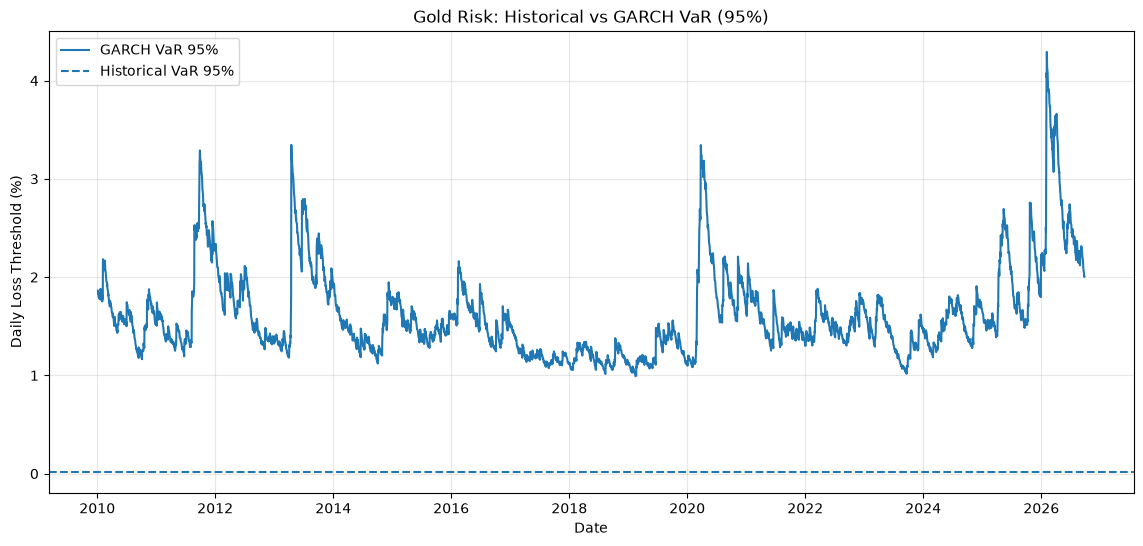

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    -gold["VaR_95_GARCH"],
    label="GARCH VaR 95%"
)

plt.axhline(
    risk_results_df.loc[
        risk_results_df["Confidence"] == "95%",
        "VaR"
    ].iloc[0],
    linestyle="--",
    label="Historical VaR 95%"
)

plt.title("Gold Risk: Historical vs GARCH VaR (95%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss Threshold (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 6. Historical vs GARCH VaR — 99%

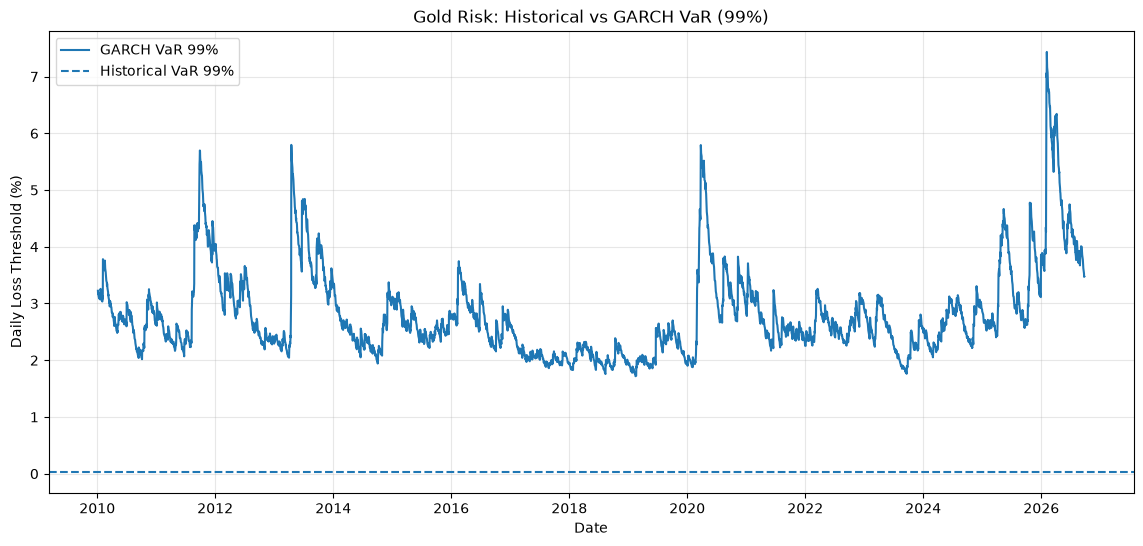

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    -gold["VaR_99_GARCH"],
    label="GARCH VaR 99%"
)

plt.axhline(
    risk_results_df.loc[
        risk_results_df["Confidence"] == "99%",
        "VaR"
    ].iloc[0],
    linestyle="--",
    label="Historical VaR 99%"
)

plt.title("Gold Risk: Historical vs GARCH VaR (99%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss Threshold (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## GARCH VaR vs Expected Shortfall

Value at Risk defines a threshold for potential downside losses,
while Expected Shortfall estimates the average loss beyond that threshold.

Comparing VaR and ES illustrates the difference between measuring
a risk boundary and measuring the severity of losses in the tail.

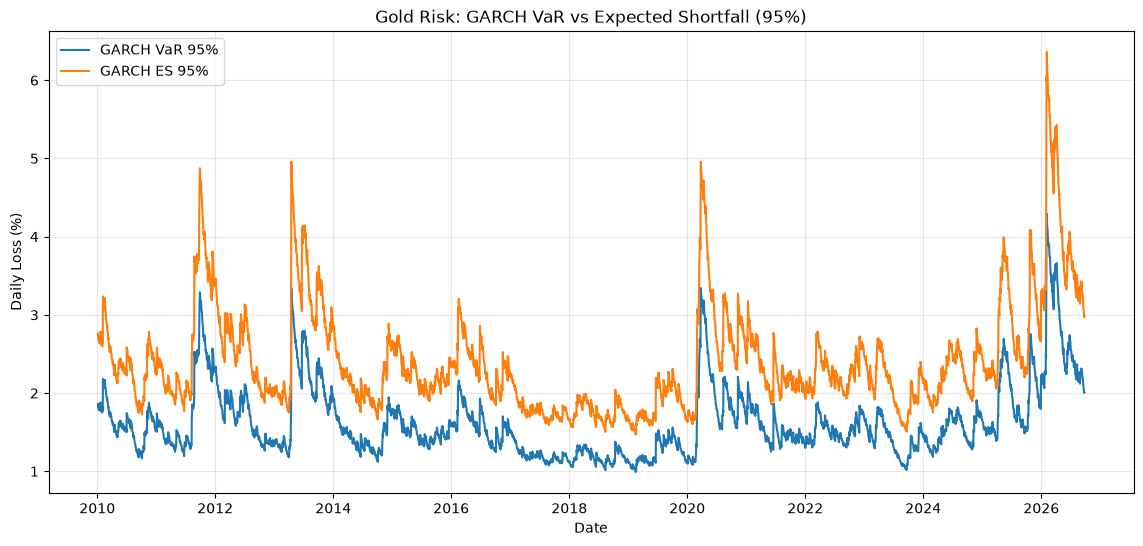

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    gold.index,
    gold["GARCH_VaR_95_Loss"],
    label="GARCH VaR 95%"
)

plt.plot(
    gold.index,
    gold["GARCH_ES_95_Loss"],
    label="GARCH ES 95%"
)

plt.title("Gold Risk: GARCH VaR vs Expected Shortfall (95%)")
plt.xlabel("Date")
plt.ylabel("Daily Loss (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
risk_file = PROCESSED_DIR / "gold_risk_metrics.csv"

gold.to_csv(risk_file)

print(f"Saved to: {risk_file}")

Saved to: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_risk_metrics.csv


## 8. Final Risk Summary

In [ ]:
historical_var_95 = risk_results_df.loc[
    risk_results_df["Confidence"] == "95%", "VaR"
].iloc[0]

historical_es_95 = risk_results_df.loc[
    risk_results_df["Confidence"] == "95%", "ES"
].iloc[0]

historical_var_99 = risk_results_df.loc[
    risk_results_df["Confidence"] == "99%", "VaR"
].iloc[0]

historical_es_99 = risk_results_df.loc[
    risk_results_df["Confidence"] == "99%", "ES"
].iloc[0]

final_risk_summary = pd.DataFrame({
    "Risk Measure": [
        "Historical VaR",
        "GARCH VaR - Average",
        "Historical ES",
        "GARCH ES - Average"
    ],
    "95%": [
        historical_var_95,
        gold["GARCH_VaR_95_Loss"].mean() / 100,
        historical_es_95,
        gold["GARCH_ES_95_Loss"].mean() / 100
    ],
    "99%": [
        historical_var_99,
        gold["GARCH_VaR_99_Loss"].mean() / 100,
        historical_es_99,
        gold["GARCH_ES_99_Loss"].mean() / 100
    ]
})

final_risk_summary.style.format({
    "95%": "{:.4%}",
    "99%": "{:.4%}"
})

,Risk Measure,95%,99%
0,Historical VaR,1.7138%,3.0673%
1,GARCH VaR - Average,1.6247%,2.8144%
2,Historical ES,2.6290%,4.3533%
3,GARCH ES - Average,2.4083%,3.8630%


## Final Risk Interpretation
The historical risk analysis shows meaningful downside tail risk in
the gold futures return series.
At the 95% confidence level, historical VaR is approximately 1.71%,
while historical Expected Shortfall is approximately 2.63%.
At the 99% confidence level, historical VaR increases to approximately
3.07%, while historical Expected Shortfall reaches approximately 4.35%.
The GARCH-based measures are dynamic and incorporate time-varying
conditional volatility.
The average GARCH VaR is approximately 1.62% at the 95% level and
2.81% at the 99% level.
The corresponding average GARCH Expected Shortfall is approximately
2.41% and 3.86%.
The difference between VaR and Expected Shortfall demonstrates the
importance of tail-risk analysis. VaR identifies a loss threshold,
whereas Expected Shortfall estimates the average severity of losses
beyond that threshold.
These results demonstrate how historical simulation and conditional
volatility modeling can be combined to obtain complementary views of
financial risk.

# Conclusion
This notebook developed a complete quantitative workflow for analyzing
gold futures volatility and downside risk.
The analysis progressed from historical price data to returns,
volatility estimation, GARCH modeling, Value at Risk, and Expected
Shortfall.
The results highlight the time-varying and heavy-tailed nature of gold
futures returns and demonstrate how statistical volatility models can
be incorporated into practical financial risk analysis.



**End of Analysis**